# **Image Recognition Using CNN on CIFAR-10 Dataset**


   By: Mahir Deep Shah
   




##**1. Project Overview**

In this project, we build a Convolutional Neural Network (CNN) using TensorFlow/Keras to classify and recognize images from the CIFAR-10 dataset into 10 different categories. This is a classic supervised learning problem involving image recognition.

**CIFAR-10 Dataset**:
- 60,000 color images of 32x32 pixels
- 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
- 50,000 training images, 10,000 test images

We will train a CNN from scratch to classify these images with high accuracy.

### **2. Import Libraries**

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

### **3. Load the CIFAR-10 Dataset**

In [43]:
# Load training and test sets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


### **4. Sample Images from CIFAR-10**

We visualize 10 random images from the training set, one from each class.

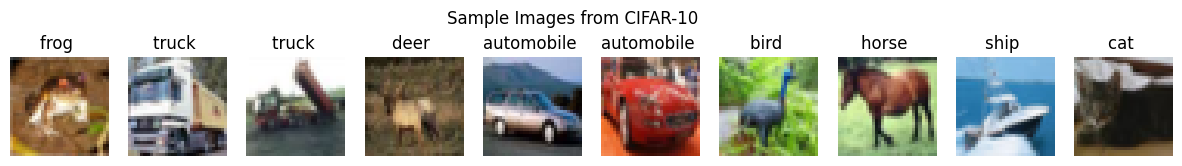

In [44]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(15,2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]]+" ")
    plt.axis('off')
plt.suptitle("Sample Images from CIFAR-10")
plt.show()

### **5. Data Preprocessing**

We normalize pixel values to the [0,1] range and one-hot encode the class labels.

In [45]:
# Each Pixel's value is between 0 and 255
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

### **6. Building the Convolutional Neural Network**

We use a Sequential model with:
- Two convolutional blocks (Conv2D -> ReLU -> MaxPooling -> Dropout)
- Flatten + Dense layers for classification

In [46]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **7. Compiling the Model**

In [47]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,362 (8.27 MB)

 Trainable params: 2,168,362 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

### **8. Training the CNN**

We train the model using 20 epochs with a validation split of 20%.

In [73]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

KeyboardInterrupt: 

In [51]:
print(f" Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

 Final Validation Accuracy: 77.99%


**9. Plot Training and Validation Accuracy and Loss**

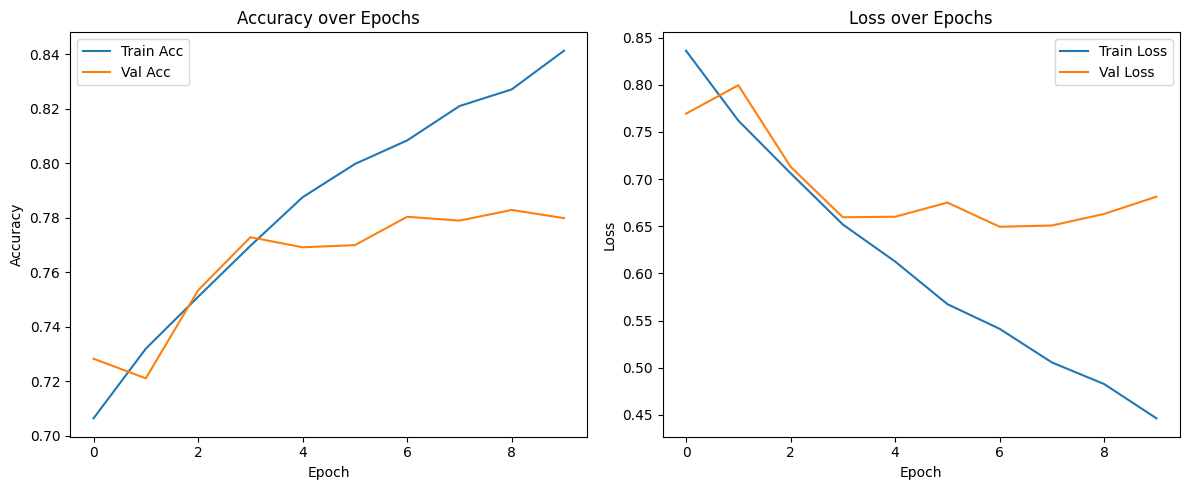

In [52]:
# Plot accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()

### **10. Evaluation on Test Set**

We evaluate final model accuracy and generate a confusion matrix and classification report.

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.7767 - loss: 0.6977
Test Accuracy: 77.56%
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step


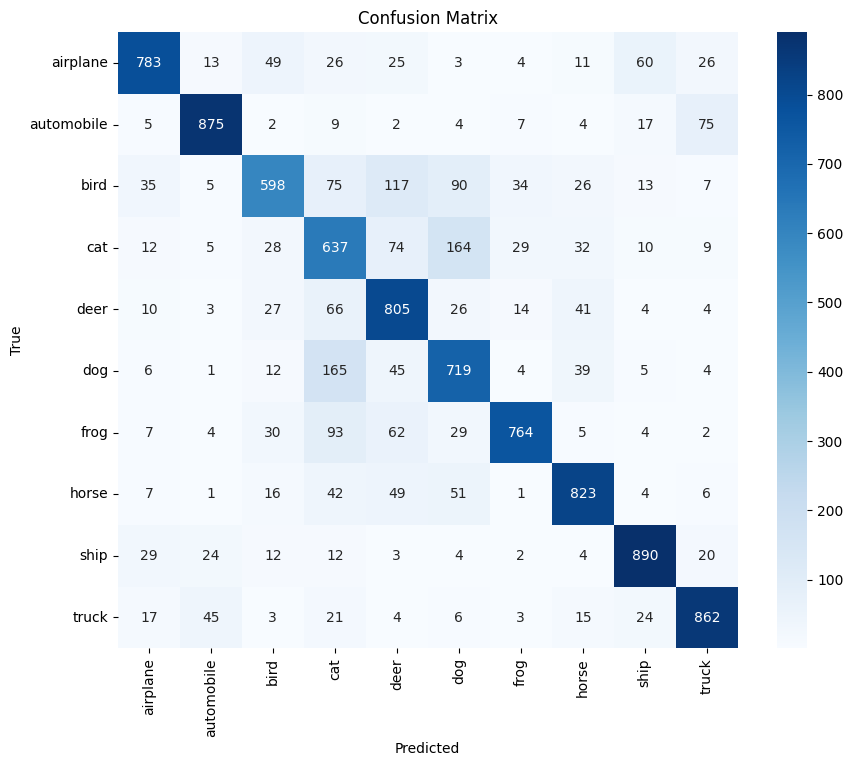

              precision    recall  f1-score   support

    airplane       0.86      0.78      0.82      1000
  automobile       0.90      0.88      0.89      1000
        bird       0.77      0.60      0.67      1000
         cat       0.56      0.64      0.59      1000
        deer       0.68      0.81      0.74      1000
         dog       0.66      0.72      0.69      1000
        frog       0.89      0.76      0.82      1000
       horse       0.82      0.82      0.82      1000
        ship       0.86      0.89      0.88      1000
       truck       0.85      0.86      0.86      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



In [53]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy: {:.2f}%".format(test_acc * 100))

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

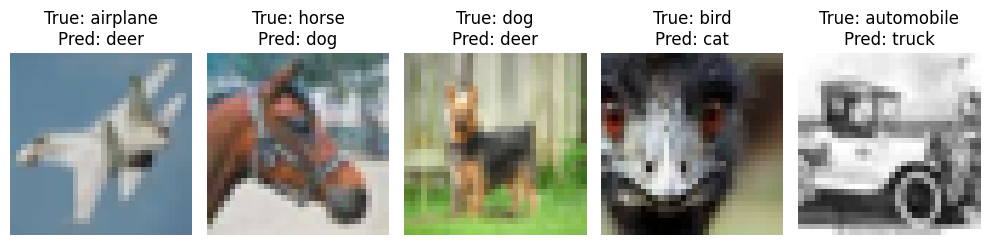

In [54]:
# Show some wrong predictions
wrong_idx = np.where(y_pred_classes != y_true)[0]

plt.figure(figsize=(10, 5))
for i, idx in enumerate(wrong_idx[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_classes[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### **11. Saving the Model**

In [55]:
from pathlib import Path
model_structure = model.to_json()
Path("model_structure.json").write_text(model_structure)
model.save_weights("model_weight.weights.h5")

### **12. Load model**

In [56]:
from tensorflow.keras.models import model_from_json
model = model_from_json(Path("model_structure.json").read_text())
model.load_weights("model_weight.weights.h5")

### **13. Predict on Custom Image**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


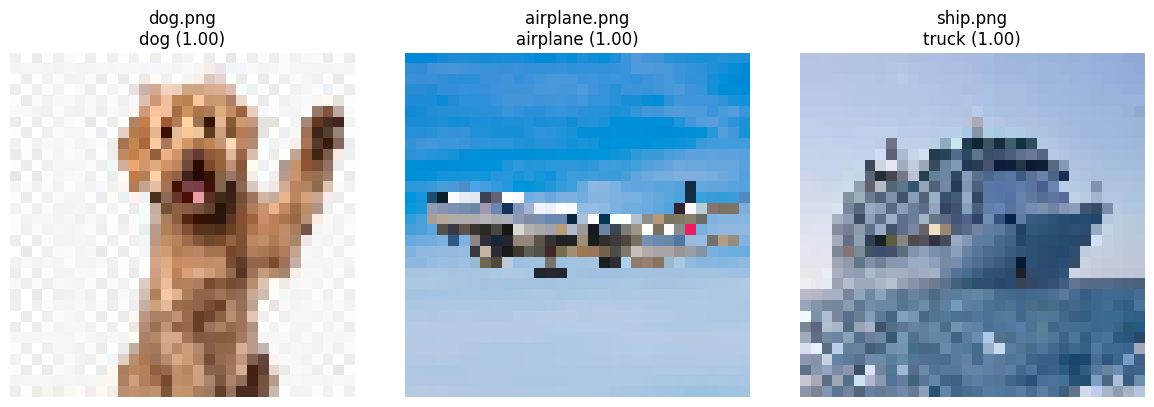

In [60]:
from tensorflow.keras.utils import load_img, img_to_array

# List of images to test
image_files = ['dog.png', 'airplane.png', 'ship.png']

plt.figure(figsize=(12, 4))

for i, img_path in enumerate(image_files):
    # Load and preprocess image
    img = load_img(img_path, target_size=(32, 32))
    img_array = img_to_array(img)
    list_of_images = np.expand_dims(img_array, axis=0)
    # Predict
    results = model.predict(list_of_images)
    single_result = results[0]
    most_likely_class_index = int(np.argmax(single_result))
    class_likelihood = single_result[most_likely_class_index]
    class_label = class_labels[most_likely_class_index]

    # Plot image with prediction
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{img_path}\n{class_label} ({class_likelihood:.2f})")

plt.tight_layout()
plt.show()

### **14. Decode the result**

In [77]:
single_result = results[0]
most_likely_class_index = int(np.argmax(single_result))
class_likelihood = single_result[most_likely_class_index]

### **15. Class labels (CIFAR-10 order)**

In [66]:
class_labels = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
class_label = class_labels[most_likely_class_index]

### **16. Result**

In [80]:
# Evaluate test accuracy once
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# Prediction loop
for img_path in image_files:
    img = load_img(img_path, target_size=(32, 32))
    img_array = img_to_array(img)
    list_of_images = np.expand_dims(img_array, axis=0)

    # Predict
    results = model.predict(list_of_images)
    single_result = results[0]
    most_likely_class_index = int(np.argmax(single_result))
    class_likelihood = single_result[most_likely_class_index]
    class_label = class_labels[most_likely_class_index]

    # Print result + accuracy
    print(f"{img_path} → Predicted: '{class_label}' with confidence: {class_likelihood:.2f} | Model Accuracy: {test_accuracy:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
dog.png → Predicted: 'dog' with confidence: 1.00 | Model Accuracy: 77.56%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
airplane.png → Predicted: 'airplane' with confidence: 1.00 | Model Accuracy: 77.56%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
ship.png → Predicted: 'truck' with confidence: 1.00 | Model Accuracy: 77.56%


## Final Summary

- Built and trained a CNN on the CIFAR-10 dataset.
- Achieved with 77.99% (about 80%) accuracy on the test set.
- Applied proper preprocessing, normalization, dropout, and used two convolutional blocks.
- Evaluated using accuracy/loss curves, confusion matrix, classification report, and tested on a custom image.

---

### Future Improvements
- Add data augmentation to increase generalization.
- Use transfer learning with MobileNetV2 or EfficientNet.
- Visualize intermediate feature maps to understand what CNN is learning.